In [6]:
#importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#ruta de los archivos y definición de los dataframes
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")


In [ ]:
#agregar columna de tipo de vino y concatenar los dataframes
red["type"] = "red"
white["type"] = "white"
df = pd.concat([red, white], ignore_index=True)

In [ ]:
#imprimir la media de calidad, alcohol y acidez volátil por tipo de vino
df.groupby("type")[["alcohol", "quality", "volatile acidity"]].mean()

,alcohol,quality,volatile acidity
type,,,
red,10.422983,5.636023,0.527821
white,10.514267,5.877909,0.278241


In [ ]:
#correlaciones entre variables
df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


In [ ]:
df[['alcohol', 'quality']].corr()
#correlación entre alcohol y calidad

,alcohol,quality
alcohol,1.000000,0.444319
quality,0.444319,1.000000


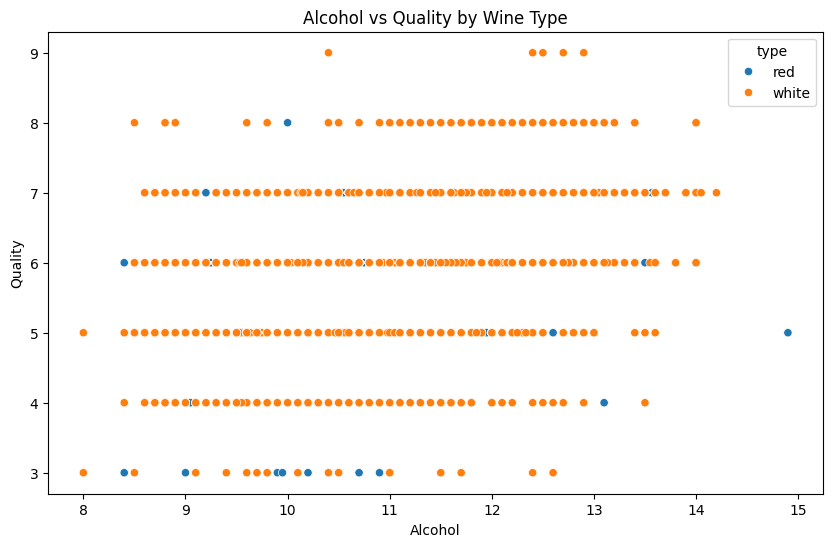

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="alcohol",
    y="quality",
    hue="type"
)

plt.title("Alcohol vs Quality by Wine Type")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

#los vinos tienen cierta relación con la cantidad de alcohol y la calidas

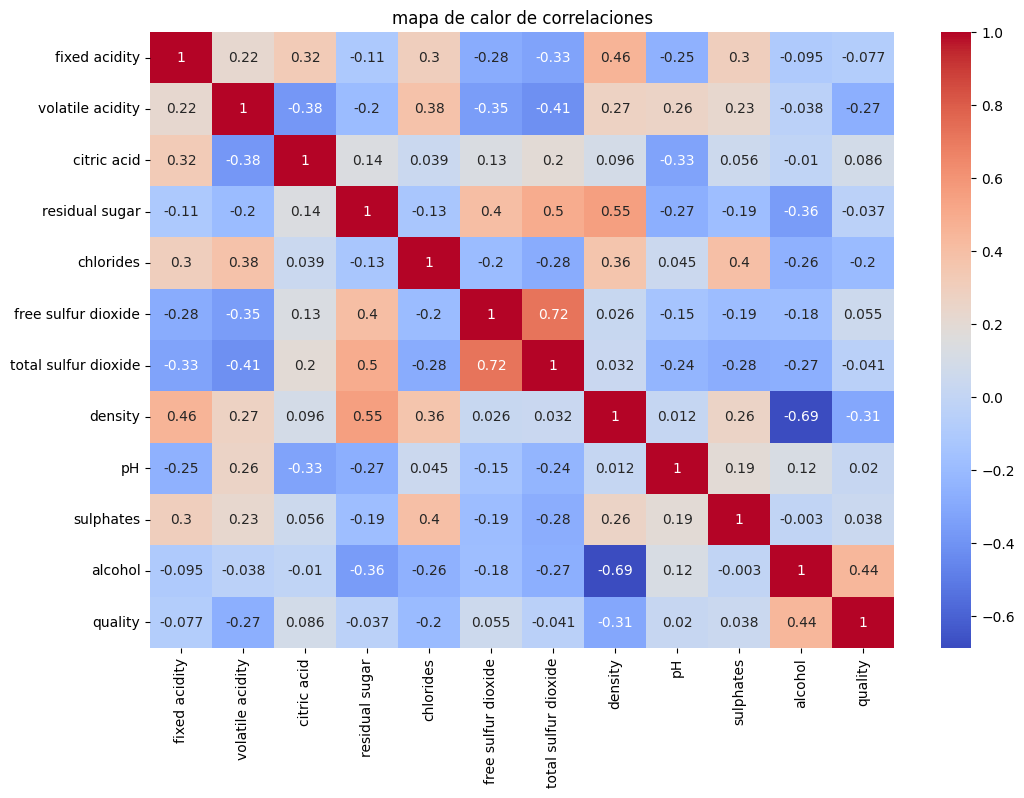

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("mapa de calor de correlaciones")
plt.show()

In [ ]:
df[['residual sugar', 'density']].corr()

#una de las correlaciones más fuertes es entre el azúcar residual y la densidad, lo que también podemos ver en el mapa

,residual sugar,density
residual sugar,1.000000,0.552517
density,0.552517,1.000000


In [ ]:
print(df.corr(numeric_only=True)["quality"].sort_values(ascending=False))
#esto nos muestra las variables que más influyen en la calidad del vino

quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


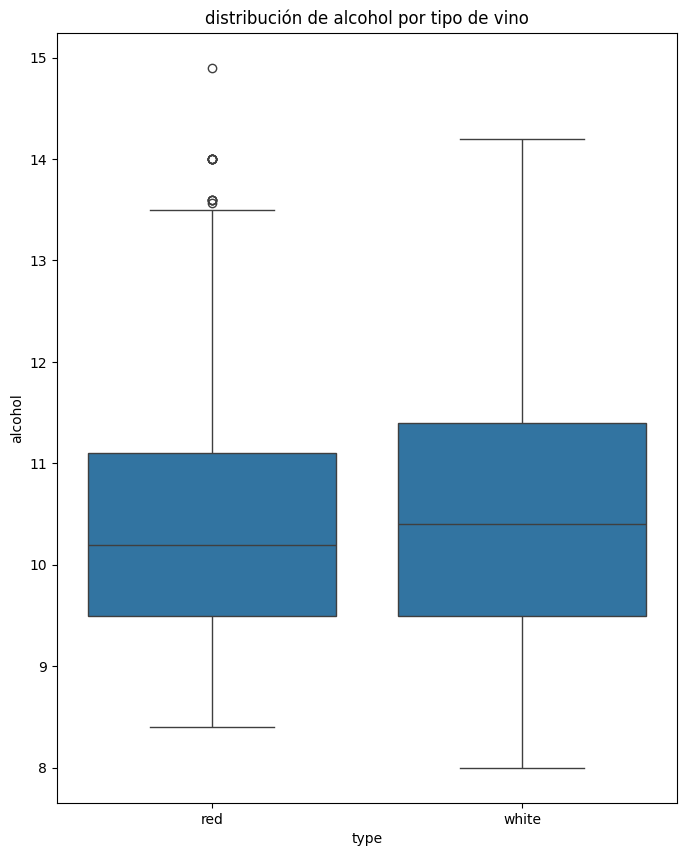

In [33]:
plt.figure(figsize=(8,10))

sns.boxplot(data=df, x="type", y="alcohol")

plt.title("distribución de alcohol por tipo de vino")
plt.show()